# Exploratory EEG Signal Analysis
the following notebook contains various methods of analysis for eeg data.   
  

In [1]:
## load libraries
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np
import cmath as cm
from scipy import signal as sps
from IPython.display import HTML

## Intro to Signal Processing
a tutorial from  [Algorithms in Neuroscience (Cognitive Computational Neuroscience - unibe)](https://aath0.github.io/AlgorithmsNeuroscience/Tutorial_files/Introduction)

### Temporal Vs. Spectral Space
The Fourier series is a series of harmonically linked (all frequencies are a multiple of the lowest frequency) sinusoids that, \
once weighted and summed, are equivalent to an arbitrary signal for the period of the fundamental \
(ie. the lowest frequency present in the signal. Or, if the signal is of a determined length, one over the length of said signal). 

To illustrate this, let us decompose a square wave signal at 440Hz with a duty cycle of 50%; \
a periodic signal oscillating from +1 to -1 440 times per second where exactly half of the signal is positive and half is negative.


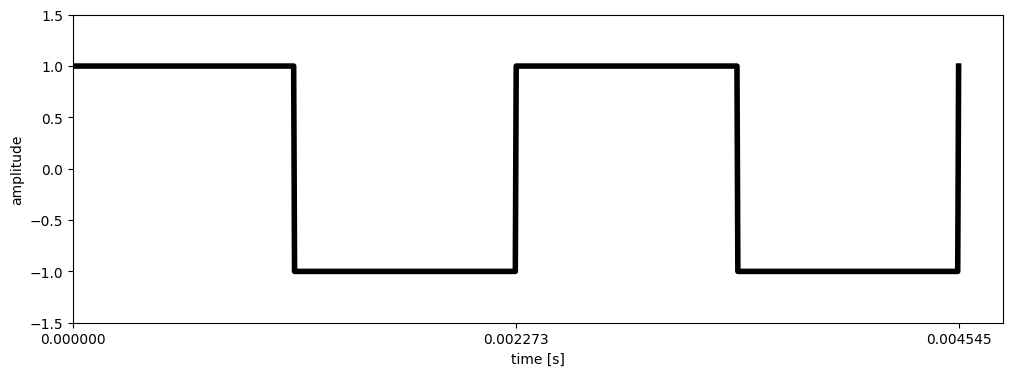

In [2]:
#This is the fundamental frequency. This is also the frequency of the first component.
fundamental = 440 
# Compute time and waveform data points
t = np.linspace(0,2/fundamental,1000);
x = sps.square(2*np.pi*440*t,0.5);
# show the waveform
fig, ax = plt.subplots(1,1,figsize=(12,4),sharex='col');

# Make the axes look nice
ax.axis([0,2.1/fundamental,-1.5,1.5]);
ax.set_xlabel('time [s]')
ax.set_ylabel('amplitude')
ax.set_xticks(np.arange(3)/fundamental)

# Draw the waveform
l1, = ax.plot(t,x,lw=4,color='k');

In [3]:
# Compute The Fourier series components
# Nframes determines how many frames the animation will have 
# each frame will add one more component, hence the number of
# frames is also the number of components to be computed
Nframes = 10;
# Set up empty line to accept the series' data
l2, = ax.plot([],[],lw=4,color='b');
# Set up empty lines to accept the components data
lines = [ax.plot([],[]) for _ in range(Nframes)];

# Add textual information on root mean square deviation
# and number of components
text = ax.text(0.0002,-1,"RMSD = {:.3}\n # of components = {:}".format(np.sqrt(np.mean(np.square(x))),0));

# Compute the components according to equation above
x_components = [4/np.pi*1/n*np.sin(2*np.pi*fundamental*n*t) for n in range(1,Nframes*2+1,2)];

# Define animation update function
def animate(i):
    # at frame 0, remove all components
    if i==0:
        for line in lines:
            line[0].set_data([],[]);
    #recompute the fourier series to the ith component
    x_series = sum(x_components[0:(i+1)],0);
    # plot series
    l2.set_data(t,x_series);
    # add new component to graph
    lines[i][0].set_data(t,x_components[i]);
    # update text
    x_rmsd = np.sqrt(np.mean(np.square(x-x_series)));
    text.set_text("RMSD = {:.3}\n # of components = {:>}".format(x_rmsd,i+1));
    
# Create animation object
ani = matplotlib.animation.FuncAnimation(fig, animate, frames=Nframes, interval = 500);
# Run animation
HTML(ani.to_jshtml())

#### Spectral representation 
The specter (or spectrum) of a signal is it's frequency signature. \
Typically, this is represented in the form of a power spectrum density (PSD): a frequency vs. power density plot. \
The amplitude of the specter at a given frequency tells how much of the power is contained at that frequency. \
Let's look at a few examples for better understanding:

In [4]:
# Initialize variables
# frequency of the periodic signals
f_signal = 4
# sampling rate
sr = 68

# timeseries vector of length 4*T (two periods(T), T = 1/f)
t = np.arange(0,4*1/f_signal,1/sr)

#### Dirac delta function (δ) 
δ is a very important function for signal processing. It is the input for a so called impulse response which helps to characterize electronic systems. \
It is also frequently present in the spectra of common signals. We will use it several times further down.

The Dirac delta function is defined as:
$$
\delta(t) = \begin{cases}
+\infty & \text{if } t = 0 \\
0 & \text{if } t \neq 0
\end{cases}
$$
 
and fulfils the condition
$$
\int_{-\infty}^{\infty} \delta(t) \, dt = 1
$$
 
In other words, it is a spike with an infinite amplitude, a width of 0 and a surface area of 1.\
This is of course impossible to use in the digital world, therefore it is expressed as:
$$
\delta(n) = \begin{cases}
sr & \text{if } n = 0 \\
0 & \text{if } n \neq 0
\end{cases}
$$
 
where  $n$ is the sample number and $sr$ is the sample rate. This creates a square pulse of amplitude sr and of width $1/sr$.\
This gives us an area under the curve of $sr⋅1/sr=1$.

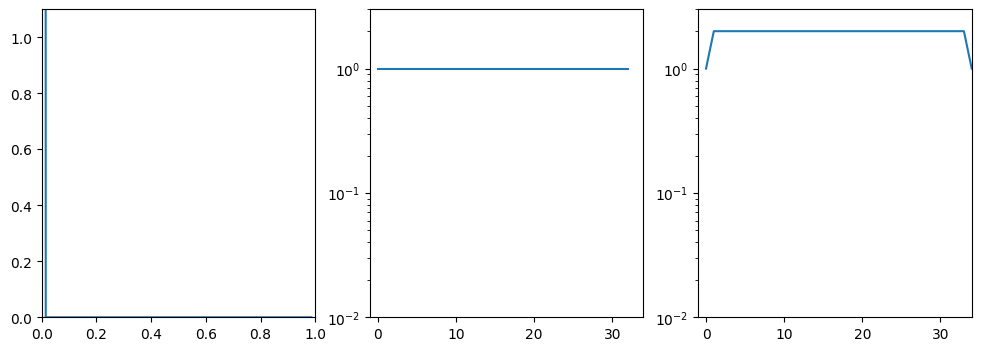

In [5]:
# Initialize figure
from scipy.signal import periodogram
fig, ax = plt.subplots(1,3,figsize=(12,4));
# Direct current(DC)
x = [0 if x !=0 else sr for x in t]
f = [0,32]
X = [1,1]
fp,Xp = periodogram(x,fs=sr,detrend=False)

ax[0].axis([0,1,0,1.1])
ax[0].plot(t,x)
ax[1].axis([-1,sr/2,10**-2,3])
ax[1].plot(f,X)
ax[1].set_yscale('log')
ax[2].axis([-1,sr/2,10**-2,3])
ax[2].plot(fp,Xp)
ax[2].set_yscale('log')

### Acquiring Data

#### What is a signal 
In neuroscience, most signals are voltage varying in time. Many bio-signals are amplified and filtered electric potentials (ie. voltages), such as ECG, EEG, EMG, etc. Others might be the result of a transducer, a device converting different physical measurements (eg. distance, pressure) to (usually) voltage. A notable exception are all video based signals, such as eye tracking. These are usually recorded as some arbitrary units directly in digital form.

In [6]:
## load libraries
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np
import cmath as cm
from scipy import signal as sps
from IPython.display import HTML

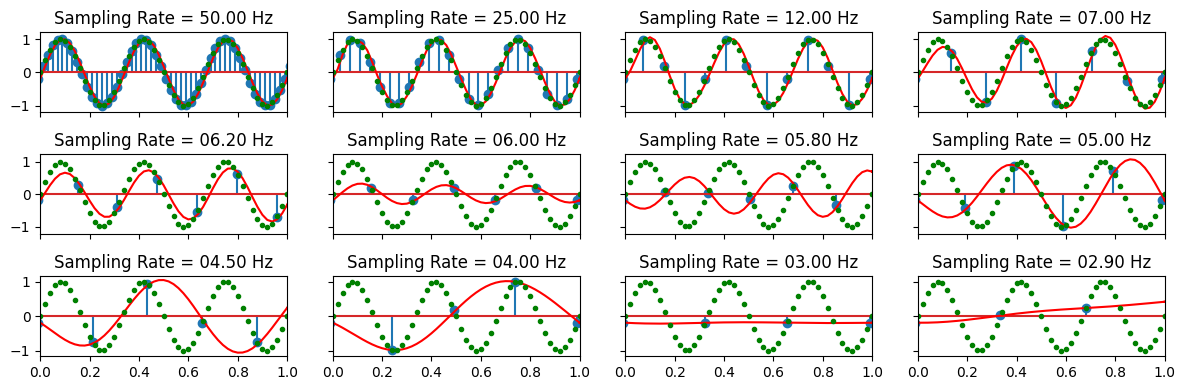

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate


# We'll use this interpolation to rebuild an analogue signal from digital samples
# credit for this implementation goes to endolith: https://gist.github.com/endolith
def sinc_interp(x, s, u):
    """
    Interpolates x, sampled at "s" instants
    Output y is sampled at "u" instants ("u" for "upsampled")
    
    from Matlab:
    http://phaseportrait.blogspot.com/2008/06/sinc-interpolation-in-matlab.html        
    """
    # Validate arguments
    if len(x) != len(s):
        raise(Exception, 'x and s must be the same length')
    
    # Find the period    
    T = s[1] - s[0]    
    
    transposed = np.transpose(np.tile(np.arange(len(s)), (len(u),1))) * T    
    
    sincM = np.tile(u, (len(s), 1)) - transposed
    y = np.dot(x, np.sinc(sincM / T))
    
    return y
        

#Set up figure
fig, axes = plt.subplots(3,4,figsize=(12,4),sharex='col',sharey='row')

# The signal will be a pure sinusoidal, at a frequency of 3 Hz (Hertz, Hz = 1/s)
frequency = 3;
# A high sampling rate (number of recorded data points per time unit) will give the
# illusion of an analog signal, you will not be able to see the time steps.
# At a lower sampling rate, you can clearly see when a point was sampled
# If the sampling rate is at or below the Nyquist frequency, the acquired signal will be erroneous.

# Now lets discretize this with a sampling rate of 10 Hz

# We'll look at a dozen frequencies
sampling_rates = [50,25,12,7,6.2,6,5.8,5,4.5,4,3,2.9];#np.logspace(np.log10(96),np.log10(1.5),num=8);

# Compare all signals to a sampling rate of 50 Hz. Used by the interpolation
reference_sampling_rate = 50;
reference_time = np.arange(-10,10,1/reference_sampling_rate);
reference_time = np.append(reference_time,1);
reference_voltage = np.sin(2*np.pi*frequency*reference_time)

# Iterate over axes and sampling rates
for (axe,sampling_rate) in zip(axes.reshape(-1),sampling_rates):
    # Create the time vector.
    time = np.arange(-10.01,10,1/sampling_rate);
    
    # Compute the sinusoidal (x = Amplitude*sin(angular_frequency * time))
    # Where angular_frequency = 2 * pi * frequency
    voltage  =  np.sin(2*np.pi*frequency*time);
    
    # In order to get a better idea of the signal represented by the samples it is interpolated
    # and plotted on top of the discretized signal. this step is not part of discretization.
    # interpolate the signal using Whittaker-Shannon Interpolation
    interpolated_voltage = sinc_interp(voltage,time,reference_time);
    
    axe.stem(time, voltage);
    axe.plot(reference_time,interpolated_voltage,'r');
    axe.plot(reference_time,reference_voltage,'g.')
    axe.set_title('Sampling Rate = {:05.2f} Hz'.format(sampling_rate))
    axe.set_xlim(0,1)

plt.tight_layout() 
plt.show()


These plots show us that there is a qualitative change in the interpolated signal when the sampling rate drops below 6 Hz. While at 6 Hz the signal still looks more or less like the original (well, kinda), at 5.8 the interpolated signal suddenly is in antiphase. Even lower, completely new signals with much lower frequency appear. Notably, at 3 Hz (the fundamental frequency of the original signal) the signal completely flattens out to a DC (Direct Current) Signal. This makes sense, since each time we take a sample, the signal will be at exactly the same amplitude.

#### Loading EEG data with MNE

1.1) Loading datasets available in MNE: EEGBCI motor imagery Dataset 
We start with a dataset that is already available in the MNE package (EEGBI motor imagery dataset). The dataset contains 64-channel EEG recordings from 109 participants and 14 runs on each participant in EDF+ format. For more details please check https://www.nmr.mgh.harvard.edu/mne/stable/manual/datasets_index.html#eegbci-motor-imagery.

In [9]:
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf

#Define the parameters 
subject = 1  # use data from subject 1
runs = [6, 10, 14]  # use only hand and feet motor imagery runs

#Get data and locate in to given path
files = eegbci.load_data(subject, runs, '../datasets/')
#Read raw data files where each file contains a run
raws = [read_raw_edf(f, preload=True) for f in files]
#Combine all loaded runs
raw_obj = concatenate_raws(raws)

Attempting to create new mne-python configuration file:
C:\Users\c_arz\.mne\mne-python.json
Extracting EDF parameters from c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\datasets\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\datasets\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\datasets\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R14.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Read

## View 

In [2]:
import math
import statistics
from typing import List, Tuple
import random

In [3]:
def simulate_eeg_data(duration_seconds: int = 60, 
                     sampling_rate: int = 256) -> List[float]:
    """
    Simulate EEG data with burst-suppression pattern for testing
    
    Args:
        duration_seconds: Length of signal in seconds
        sampling_rate: Samples per second
        
    Returns:
        Simulated EEG signal
    """
    n_samples = duration_seconds * sampling_rate
    signal = []
    
    # Generate baseline suppression
    for i in range(n_samples):
        signal.append(random.gauss(0, 0.5))
    
    # Add random bursts
    n_bursts = random.randint(5, 15)
    for _ in range(n_bursts):
        burst_start = random.randint(0, n_samples - sampling_rate)
        burst_duration = random.randint(sampling_rate//4, sampling_rate)
        
        for i in range(burst_start, min(burst_start + burst_duration, n_samples)):
            signal[i] = random.gauss(0, 2.0)  # Higher amplitude for bursts
            
    return signal

In [5]:
class BurstDetector:
    def __init__(self, window_size: int = 1000, threshold_factor: float = 2.0):
        self.window_size = window_size
        self.threshold_factor = threshold_factor
        
    def detect_bursts(self, eeg_signal: List[float]) -> List[Tuple[int, int]]:
        """
        Detect bursts in EEG signal using adaptive thresholding
        
        Args:
            eeg_signal: Raw EEG signal values
            
        Returns:
            List of (start, end) indices for detected bursts
        """
        bursts = []
        
        # Calculate rolling variance
        variances = self._calculate_rolling_variance(eeg_signal)
        
        # Adaptive threshold based on signal statistics
        threshold = statistics.mean(variances) * self.threshold_factor
        
        # Detect burst segments
        in_burst = False
        burst_start = 0
        
        for i in range(len(variances)):
            if variances[i] > threshold and not in_burst:
                in_burst = True
                burst_start = i
            elif variances[i] <= threshold and in_burst:
                in_burst = False
                bursts.append((burst_start, i))
                
        return bursts
    
    def _calculate_rolling_variance(self, signal: List[float]) -> List[float]:
        """Calculate rolling variance with specified window size"""
        variances = []
        for i in range(len(signal)):
            start_idx = max(0, i - self.window_size)
            window = signal[start_idx:i+1]
            variance = statistics.variance(window) if len(window) > 1 else 0
            variances.append(variance)
        return variances
    
    def calculate_bursts_per_minute(self, bursts: List[Tuple[int, int]], 
                                  sampling_rate: int) -> float:
        """
        Calculate bursts per minute from detected bursts
        
        Args:
            bursts: List of (start, end) burst indices
            sampling_rate: EEG sampling rate in Hz
            
        Returns:
            Bursts per minute
        """
        total_time_seconds = len(bursts) / sampling_rate
        return len(bursts) * (60 / total_time_seconds)

In [7]:
# Simulate 5 minutes of EEG data
sampling_rate = 256  # Hz
duration = 5 * 60    # 5 minutes
eeg_data = simulate_eeg_data(duration, sampling_rate)
    
# Initialize and run burst detector
detector = BurstDetector(window_size=sampling_rate)
bursts = detector.detect_bursts(eeg_data)
    
# Calculate and display results
bpm = detector.calculate_bursts_per_minute(bursts, sampling_rate)
    
print(f"Detected {len(bursts)} bursts")
print(f"Bursts per minute: {bpm:.2f}")
    
# Print first few bursts timing
for i, (start, end) in enumerate(bursts[:5]):
    burst_duration = (end - start) / sampling_rate
    print(f"Burst {i+1}: {burst_duration:.2f} seconds")

Detected 15 bursts
Bursts per minute: 15360.00
Burst 1: 0.00 seconds
Burst 2: 1.48 seconds
Burst 3: 1.15 seconds
Burst 4: 1.60 seconds
Burst 5: 1.36 seconds


NameError: name 'variances' is not defined